In [100]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F

# Keypoints

In [101]:
mp_holistic = mp.solutions.holistic 
mp_drawing = mp.solutions.drawing_utils 

In [102]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False                 
    results = model.process(image)                 
    image.flags.writeable = True              
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  
    return image, results

In [103]:
def draw_landmarks(image, results):
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) 
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) 
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) 
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

In [104]:
def draw_styled_landmarks(image, results):
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
    #                          mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
    #                          mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
    #                          ) 
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [105]:
cap = cv2.VideoCapture(0)
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        ret, frame = cap.read()

        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        draw_styled_landmarks(image, results)

        cv2.imshow('OpenCV Feed', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [106]:
draw_landmarks(frame, results)

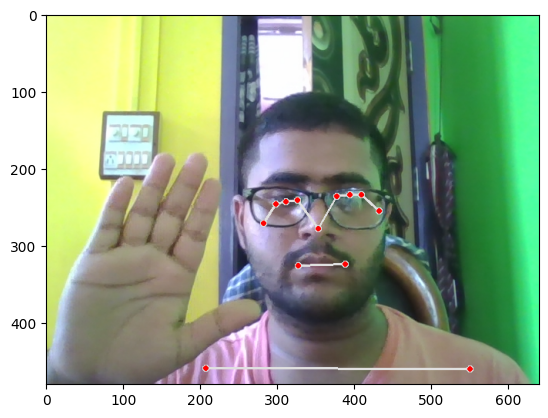

In [107]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Extract Keypoint Values

In [108]:
if results.face_landmarks:
    print("Face landmarks:", len(results.face_landmarks.landmark))

if results.pose_landmarks:
    print("Pose landmarks:", len(results.pose_landmarks.landmark))

if results.left_hand_landmarks:
    print("Left hand landmarks:", len(results.left_hand_landmarks.landmark))

if results.right_hand_landmarks:
    print("Right hand landmarks:", len(results.right_hand_landmarks.landmark))


Face landmarks: 468
Pose landmarks: 33


In [109]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [110]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [111]:
def extract_keypoints(results):
    # Pose: only x,y,z → 33×3 = 99 dims
    pose = (
        np.array([[res.x, res.y, res.z] 
                  for res in results.pose_landmarks.landmark])
        .flatten()
        if results.pose_landmarks
        else np.zeros(33 * 3)
    )

    # Left hand: 21×3 = 63 dims
    lh = (
        np.array([[res.x, res.y, res.z] 
                  for res in results.left_hand_landmarks.landmark])
        .flatten()
        if results.left_hand_landmarks
        else np.zeros(21 * 3)
    )

    # Right hand: 21×3 = 63 dims
    rh = (
        np.array([[res.x, res.y, res.z] 
                  for res in results.right_hand_landmarks.landmark])
        .flatten()
        if results.right_hand_landmarks
        else np.zeros(21 * 3)
    )

    return np.concatenate([pose, lh, rh])  # 99 + 63 + 63 = 225


# Folder Setup

In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [113]:
import json

# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data_gloss') 
VIDEO_PATH = os.path.join('../../datasets/ISL_Gifs')
GLOSS_PATH = os.path.join('../../datasets/invGlossList.json')
KEY_JSON_PATH = "test2keypoints_dataset.json"

# Actions that we try to detect
with open(GLOSS_PATH, 'r') as f:
    gloss = json.load(f)
    
actions = np.array(list(gloss.keys()))
print(f"Actions: {actions}")

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 1

Actions: ['a' 'address' 'ahemdabad' 'all' 'any questions' 'are you angry'
 'are you hungry' 'assam' 'august' 'b' 'banana' 'banaras' 'banglore'
 'be careful' 'bridge' 'c' 'cat' 'christmas' 'church' 'cilinic' 'd'
 'dasara' 'december' 'did you finish homework' 'do you have money'
 'do you want something to drink' 'do you watch tv' 'dont worry' 'e' 'f'
 'flower is beautiful' 'g' 'good afternoon' 'good morning' 'good question'
 'grapes' 'h' 'hello' 'hindu' 'hyderabad' 'i am a clerk' 'i am fine'
 'i am sorry' 'i am thinking' 'i am tired' 'i go to a theatre'
 'i had to say something but i forgot' 'i like pink colour'
 'i love to shop' 'job' 'july' 'june' 'karnataka' 'kerala' 'krishna' 'l'
 'lets go for lunch' 'm' 'mango' 'may' 'mile' 'mumbai' 'nagpur'
 'nice to meet you' 'open the door' 'p' 'pakistan' 'please call me later'
 'police station' 'post office' 'pune' 'punjab' 'saturday'
 'shall i help you' 'shall we go together tommorow' 'shop'
 'sign language interpreter' 'sit down' 'stand up' 't

In [114]:
for action in actions: 
    if not os.path.exists(os.path.join(DATA_PATH, action)):
        os.makedirs(os.path.join(DATA_PATH, action))
    dirmax = np.max(np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int)) if os.listdir(os.path.join(DATA_PATH, action)) else 0
    for sequence in range(1,no_sequences+1):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(dirmax+sequence)))
        except:
            pass

# Keypoint Value Collection

In [115]:
# cap = cv2.VideoCapture(0)

action_index = 0
stop_all = False

mp_drawing    = mp.solutions.drawing_utils
mp_pose_conn  = mp_holistic.POSE_CONNECTIONS
mp_left_conn  = mp_holistic.HAND_CONNECTIONS
mp_right_conn = mp_holistic.HAND_CONNECTIONS

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    while action_index < len(actions) and not stop_all:
        action = actions[action_index]
        gloss_vid = gloss[action][0]
        action_vid_path = os.path.join(VIDEO_PATH,gloss_vid + '.gif')
        if not os.path.exists(action_vid_path):
            print(f"Skipping path ==> {action_vid_path}")
            action_index += 1
            continue        
        cap = cv2.VideoCapture(action_vid_path)

        
        print(f"Starting action: {action}")

        for sequence in range(start_folder, start_folder + no_sequences):
            for frame_num in range(sequence_length):
                ret, frame = cap.read()
                if not ret:
                    continue

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                # draw_styled_landmarks(image, results)
                if results.pose_landmarks:
                    mp_drawing.draw_landmarks(
                        image,
                        results.pose_landmarks,
                        mp_pose_conn,
                        mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                        mp_drawing.DrawingSpec(color=(0,0,255), thickness=2)
                    )

                if results.left_hand_landmarks:
                    mp_drawing.draw_landmarks(
                        image,
                        results.left_hand_landmarks,
                        mp_left_conn,
                        mp_drawing.DrawingSpec(color=(255,255,0), thickness=2, circle_radius=2),
                        mp_drawing.DrawingSpec(color=(255,0,255), thickness=2)
                    )
                if results.right_hand_landmarks:
                    mp_drawing.draw_landmarks(
                        image,
                        results.right_hand_landmarks,
                        mp_right_conn,
                        mp_drawing.DrawingSpec(color=(255,255,0), thickness=2, circle_radius=2),
                        mp_drawing.DrawingSpec(color=(255,0,255), thickness=2)
                    )

                # Display status text
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 4, cv2.LINE_AA)
                    cv2.putText(image, f'Collecting for {action} Video {sequence}', (15,12), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else:
                    cv2.putText(image, f'Collecting for {action} Video {sequence}', (15,12), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)

                # Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                if not os.path.exists(os.path.dirname(npy_path)):
                    os.makedirs(os.path.dirname(npy_path))
                if not os.path.exists(npy_path + '.npy'):
                    np.save(npy_path, keypoints)

                # Handle key presses
                key = cv2.waitKey(10) & 0xFF
                if key == ord('q'):
                    print("Frame loop break (q pressed).")
                    break  # exit current sequence early
                elif key == 27:  # ESC
                    print("ESC pressed. Stopping all collection.")
                    stop_all = True
                    break
                elif stop_all or key in [ord('q'), 83, 2555904]:
                    break
            if key == 83 or key == 2555904:  # Right arrow key
                print("Right arrow pressed. Skipping to next action.")
                break

        action_index += 1

cap.release()
cv2.destroyAllWindows()


Starting action: a
Starting action: address
Starting action: ahemdabad
Starting action: all
Starting action: any questions
Starting action: are you angry
Starting action: are you hungry
Starting action: assam
Starting action: august
Starting action: b
Starting action: banana
Starting action: banaras
Starting action: banglore
Starting action: be careful
Starting action: bridge
Starting action: c
Starting action: cat
Starting action: christmas
Starting action: church
Starting action: cilinic
Starting action: d
Starting action: dasara
Starting action: december
Starting action: did you finish homework
Starting action: do you have money
Starting action: do you want something to drink
Starting action: do you watch tv
Starting action: dont worry
Starting action: e
Starting action: f
Starting action: flower is beautiful
Starting action: g
Starting action: good afternoon
Starting action: good morning
Starting action: good question
Starting action: grapes
Starting action: h
Starting action: hell

# Preprocess, Labels and Feats

In [116]:
dataset_entries = []

for action in actions:
    action_dir = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_dir):
        print(f"[!] Missing action dir: {action_dir}")
        continue
    
    for sequence in sorted(os.listdir(action_dir), key = lambda x: int(x)):
        sequence_path = os.path.join(action_dir, sequence)
        if not os.path.isdir(sequence_path):
            print(f"[!] Missing Sequence: {sequence_path}")
            continue
        
        frame_files = [f for f in os.listdir(sequence_path) if f.endswith('.npy')]
        if len(frame_files) < 30:
            print(f"[!] Skipping Incomplete Sequence: {action}/{sequence} (only {len(frame_files)} frames)")
            continue
        
        dataset_entries.append({
            "text": action,
            "keypoints_path": sequence_path.replace("\\", "/")
        })
        
output_path = "test2keypoints_dataset.json"
with open(output_path, 'w') as f:
    json.dump(dataset_entries, f, indent=2)
    
print(f"[+] Dataset length: {len(dataset_entries)}")

[!] Skipping Incomplete Sequence: a/1 (only 1 frames)
[!] Skipping Incomplete Sequence: a/2 (only 0 frames)
[!] Skipping Incomplete Sequence: a/3 (only 0 frames)
[!] Skipping Incomplete Sequence: a/4 (only 0 frames)
[!] Skipping Incomplete Sequence: a/5 (only 0 frames)
[!] Skipping Incomplete Sequence: a/6 (only 0 frames)
[!] Skipping Incomplete Sequence: a/7 (only 0 frames)
[!] Skipping Incomplete Sequence: a/8 (only 0 frames)
[!] Skipping Incomplete Sequence: a/9 (only 0 frames)
[!] Skipping Incomplete Sequence: a/10 (only 0 frames)
[!] Skipping Incomplete Sequence: a/11 (only 0 frames)
[!] Skipping Incomplete Sequence: a/12 (only 0 frames)
[!] Skipping Incomplete Sequence: a/13 (only 0 frames)
[!] Skipping Incomplete Sequence: a/14 (only 0 frames)
[!] Skipping Incomplete Sequence: a/15 (only 0 frames)
[!] Skipping Incomplete Sequence: a/16 (only 0 frames)
[!] Skipping Incomplete Sequence: a/17 (only 0 frames)
[!] Skipping Incomplete Sequence: a/18 (only 0 frames)
[!] Skipping Incomp

In [117]:
label_map = {label:num for num, label in enumerate(actions)}
label_map

{'a': 0,
 'address': 1,
 'ahemdabad': 2,
 'all': 3,
 'any questions': 4,
 'are you angry': 5,
 'are you hungry': 6,
 'assam': 7,
 'august': 8,
 'b': 9,
 'banana': 10,
 'banaras': 11,
 'banglore': 12,
 'be careful': 13,
 'bridge': 14,
 'c': 15,
 'cat': 16,
 'christmas': 17,
 'church': 18,
 'cilinic': 19,
 'd': 20,
 'dasara': 21,
 'december': 22,
 'did you finish homework': 23,
 'do you have money': 24,
 'do you want something to drink': 25,
 'do you watch tv': 26,
 'dont worry': 27,
 'e': 28,
 'f': 29,
 'flower is beautiful': 30,
 'g': 31,
 'good afternoon': 32,
 'good morning': 33,
 'good question': 34,
 'grapes': 35,
 'h': 36,
 'hello': 37,
 'hindu': 38,
 'hyderabad': 39,
 'i am a clerk': 40,
 'i am fine': 41,
 'i am sorry': 42,
 'i am thinking': 43,
 'i am tired': 44,
 'i go to a theatre': 45,
 'i had to say something but i forgot': 46,
 'i like pink colour': 47,
 'i love to shop': 48,
 'job': 49,
 'july': 50,
 'june': 51,
 'karnataka': 52,
 'kerala': 53,
 'krishna': 54,
 'l': 55,
 '

In [118]:
class T2SDataset(Dataset):
    def __init__(self, json_path, sequence_length=30, feature_dim=1662, max_text_len=10):
        with open(json_path, 'r') as f:
            self.data = json.load(f)

        self.sequence_length = sequence_length
        self.feature_dim = feature_dim
        self.max_text_len = max_text_len

        all_text = [entry['text'] for entry in self.data]
        vocab_words = set(word for t in all_text for word in t.lower().split())
        self.vocab = {'<PAD>': 0, '<UNK>': 1}
        self.vocab.update({word: idx+2 for idx, word in enumerate(sorted(vocab_words))})

    def __len__(self):
        return len(self.data)

    def text_to_tensor(self, text):
        tokens = text.lower().split()
        ids = [self.vocab.get(tok, self.vocab['<UNK>']) for tok in tokens]
        ids += [self.vocab['<PAD>']] * (self.max_text_len - len(ids))
        return torch.tensor(ids[:self.max_text_len])

    def __getitem__(self, idx):
        item = self.data[idx]
        x = self.text_to_tensor(item["text"])
        y = []

        for i in range(self.sequence_length):
            path = os.path.join(item["keypoints_path"], f"{i}.npy")
            if os.path.exists(path):
                kp = np.load(path)
            else:
                kp = y[-1] if y else np.zeros(self.feature_dim)
            y.append(kp)
        
        y = np.stack(y)
        return x, torch.tensor(y, dtype=torch.float32)

# LSTM Model Arch

## LSTM Model

In [119]:
class LSTM_t2s(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=1):
        super(LSTM_t2s, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim * 30)
        self.output_dim = output_dim

    def forward(self, x):
        embedded = self.embedding(x)  # (B, T, D)
        _, (hn, _) = self.lstm(embedded)
        output = self.fc(hn[-1])
        return output.view(-1, 30, self.output_dim)

## Transformer LSTM

In [120]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)                # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)   # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)       
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))       # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return x

class Text2SignHybrid(nn.Module):
    def __init__(self,
                 vocab_size: int,
                 embed_dim: int,
                 trans_dim: int,
                 lstm_hidden: int,
                 num_layers: int,
                 output_dim: int,
                 seq_len: int = 30,
                 num_heads: int = 4,
                 tcn_channels: list = [128, 64]):
        super().__init__()
        self.seq_len = seq_len
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model=embed_dim, max_len=seq_len)
        
        # ----- Transformer Encoder --------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead= num_heads,
            dim_feedforward=trans_dim,
            dropout=0.1,
            activation='relu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # --------- LSTM Decoder ------------
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1
        )
        
        # -------------- Temporal Convolutional Refinement ---------------
        tcn_layers = []
        in_ch = lstm_hidden
        for out_ch in tcn_channels:
            tcn_layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.BatchNorm1d(out_ch)
            ]
            in_ch = out_ch
        self.tcn = nn.Sequential(*tcn_layers)
        
        # ---- Final projection ---
        self.fc = nn.Linear(tcn_channels[-1], output_dim)
        

    def forward(self, x):
        B = x.size(0)
        
        emb = self.embedding(x)                # (B, T_text, embed_dim)
        emb = self.pos_enc(emb)                # "
        
        tr_in = emb.permute(1,0,2)             # (T_text, B, D)
        tr_out = self.transformer(tr_in)       # (T_text, B, D)
        tr_out = tr_out.permute(1,0,2)         # (B, T_text, D)
        

        token_ctx = tr_out[:, -1, :].unsqueeze(1)  # (B,1,D)
        dec_input = token_ctx.repeat(1, self.seq_len, 1)  # (B, seq_len, D)
        
        lstm_out, _ = self.lstm(dec_input)     # (B, seq_len, lstm_hidden)
        
        #  (B, C, T)
        tcn_in = lstm_out.permute(0,2,1)      # (B, lstm_hidden, seq_len)
        tcn_out = self.tcn(tcn_in)             # (B, last_ch, seq_len)
        
        tcn_out = tcn_out.permute(0,2,1)       # (B, seq_len, last_ch)
        # out   = self.fc(tcn_out)             # (B, seq_len, output_dim)
        out = torch.sigmoid(self.fc(tcn_out))

        return out


# Training Setup

In [121]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_model(json_path, num_epochs=10, batch_size=8, lr=1e-3):
    dataset = T2SDataset(json_path)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    # model = LSTM_t2s(
    #     vocab_size=len(dataset.vocab),
    #     embed_dim=128,
    #     hidden_dim=512,
    #     output_dim=1662
    # )
    
    model = Text2SignHybrid(
        vocab_size  = len(dataset.vocab),
        output_dim  = 225,        
        seq_len     = 30,          
        embed_dim   = 128,        
        trans_dim   = 256,         
        lstm_hidden = 512,         
        num_layers  = 2,           
        num_heads   = 4,           
        tcn_channels= [128, 64]
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[=] Device: {device}")
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(1000):
        model.train()
        running_loss = 0.0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss / len(dataloader):.4f}")

    torch.save(model.state_dict(), "text2sign_model.pth")
    np.save("alt_model_vocab.npy", dataset.vocab)
    print("[+] Model saved to text2sign_model.pth")
    return model, dataset.vocab


In [122]:
MODEL, VOCAB = train_model(KEY_JSON_PATH)

[=] Device: cuda
Epoch 1/10 - Loss: 0.3370
Epoch 2/10 - Loss: 0.3267
Epoch 3/10 - Loss: 0.3204
Epoch 4/10 - Loss: 0.3155
Epoch 5/10 - Loss: 0.3105
Epoch 6/10 - Loss: 0.3052
Epoch 7/10 - Loss: 0.2990
Epoch 8/10 - Loss: 0.2917
Epoch 9/10 - Loss: 0.2836
Epoch 10/10 - Loss: 0.2743
Epoch 11/10 - Loss: 0.2643
Epoch 12/10 - Loss: 0.2534
Epoch 13/10 - Loss: 0.2413
Epoch 14/10 - Loss: 0.2295
Epoch 15/10 - Loss: 0.2168
Epoch 16/10 - Loss: 0.2043
Epoch 17/10 - Loss: 0.1921
Epoch 18/10 - Loss: 0.1811
Epoch 19/10 - Loss: 0.1705
Epoch 20/10 - Loss: 0.1609
Epoch 21/10 - Loss: 0.1523
Epoch 22/10 - Loss: 0.1448
Epoch 23/10 - Loss: 0.1383
Epoch 24/10 - Loss: 0.1329
Epoch 25/10 - Loss: 0.1288
Epoch 26/10 - Loss: 0.1247
Epoch 27/10 - Loss: 0.1213
Epoch 28/10 - Loss: 0.1182
Epoch 29/10 - Loss: 0.1162
Epoch 30/10 - Loss: 0.1139
Epoch 31/10 - Loss: 0.1117
Epoch 32/10 - Loss: 0.1106
Epoch 33/10 - Loss: 0.1090
Epoch 34/10 - Loss: 0.1075
Epoch 35/10 - Loss: 0.1066
Epoch 36/10 - Loss: 0.1055
Epoch 37/10 - Loss: 

In [123]:
np.save("alt_model_vocab.npy", VOCAB)